# Introduction

---

# Importing Libraries & Loading Data

In [351]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# configuration
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [352]:
df = pd.read_csv('data/final_dataset.csv', index_col='year')

# Dataset Description

In [353]:
df.head()

,birth_count,employed_population,gdp_per_capita,monthly_salary,unemployment_rate,industrial_production,inst_preschool,inst_general_school,inst_elementary,inst_junior,...,grad_vocational,grad_secondary_special,grad_higher,edu_exp_total,edu_exp_preschool,edu_exp_secondary,edu_exp_higher,inst_total,teachers_total,grad_total
year,,,,,,,,,,,,,,,,,,,,,
2011,149612,2277693,54400,9304,0.09,164361100000.00,741,2204,125,202,...,28100,15500,41800,19420400000,1650700000,12574600000,2442400000,5438,102104,243000
2012,154918,2286400,58000,10726,0.08,137229200000.00,819,2201,118,222,...,25400,16400,41700,22925900000,2153200000,14956600000,2757100000,5517,103102,233800
2013,155520,2263000,65000,11341,0.08,169829400000.00,927,2207,115,202,...,27500,17900,41300,24089700000,2576500000,14852100000,3078100000,5637,103953,231600
2014,161813,2302704,71800,12285,0.08,171108900000.00,1062,2205,115,203,...,25500,23000,40800,25915400000,2948800000,15102600000,3412300000,5755,102660,230700
2015,163452,2352100,75500,13483,0.08,181026700000.00,1186,2218,115,200,...,25700,27100,41700,29995000000,3721600000,16997200000,3854200000,5905,106125,237000


In [354]:
df.shape

(14, 33)

In [355]:
df.columns.tolist()

['birth_count',
 'employed_population',
 'gdp_per_capita',
 'monthly_salary',
 'unemployment_rate',
 'industrial_production',
 'inst_preschool',
 'inst_general_school',
 'inst_elementary',
 'inst_junior',
 'inst_high',
 'inst_special_needs',
 'inst_vocational',
 'inst_secondary_special',
 'inst_higher',
 'teachers_preschool',
 'teachers_general_school',
 'teachers_special_needs',
 'teachers_vocational',
 'teachers_secondary_special',
 'teachers_higher',
 'grad_secondary_9',
 'grad_secondary_11',
 'grad_vocational',
 'grad_secondary_special',
 'grad_higher',
 'edu_exp_total',
 'edu_exp_preschool',
 'edu_exp_secondary',
 'edu_exp_higher',
 'inst_total',
 'teachers_total',
 'grad_total']

The dataset contains *14 observations* and *33 features*, covering socio-economic and education-related indicators.

- **birth_count** — number of births per year  
- **employed_population** — total employed population  
- **gdp_per_capita** — GDP per capita (som)
- **monthly_salary** — average monthly salary  
- **unemployment_rate** — unemployment rate (%)  
- **industrial_production** — industrial production output (som) 

> `inst_` — number of educational institutions by level  
- **inst_preschool** — preschool institutions  
- **inst_general_school** — general education schools  
- **inst_elementary** — elementary schools (grades 1–4)  
- **inst_junior** — lower secondary schools (grades 5–9)  
- **inst_high** — upper secondary schools (grades 10–11)  
- **inst_special_needs** — institutions for students with special needs  
- **inst_vocational** — vocational schools  
- **inst_secondary_special** — secondary specialized institutions  
- **inst_higher** — higher education institutions (universities)  

> `teachers_` — number of teachers in the corresponding institutions  
- **teachers_preschool** — preschool teachers  
- **teachers_general_school** — teachers in general schools  
- **teachers_special_needs** — teachers in special needs institutions  
- **teachers_vocational** — vocational education teachers  
- **teachers_secondary_special** — teachers in secondary specialized institutions  
- **teachers_higher** — university teachers  

> `grad_` — number of graduates by education level  
- **grad_secondary_9** — graduates of grade 9  
- **grad_secondary_11** — graduates of grade 11  
- **grad_vocational** — vocational program graduates  
- **grad_secondary_special** — graduates of secondary specialized institutions  
- **grad_higher** — higher education graduates

> `edu_exp` - amount of state budget expenditures by level
- **edu_exp_preschool** - expenditures on preschool education
- **edu_exp_secondary** - expenditures on secondary education
- **edu_exp_higher** - expenditures on higher education

> Aggregated features
- **inst_total** — total number of educational institutions across all levels  
- **teachers_total** — total number of teachers across all institution types  
- **grad_total** — total number of graduates across all education levels
- **edu_exp_total** - total amount of state budget expenditures on education

# Descriptive Statistics

In [356]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
birth_count,14.00,156187.50,9163.68,140419.00,150179.25,155219.00,160899.75,173484.00
employed_population,14.00,2428456.93,151687.05,2263000.00,2314828.00,2373100.00,2514725.00,2756000.00
gdp_per_capita,14.00,103300.00,48989.45,54400.00,72725.00,88850.00,110525.00,219200.00
monthly_salary,14.00,18126.86,7992.76,9304.00,12584.50,16048.50,19232.50,36047.00
unemployment_rate,14.00,0.06,0.02,0.04,0.05,0.07,0.08,0.09
industrial_production,14.00,288460821992.86,140590380190.12,137229200000.00,173588350000.00,247286900000.00,359172875000.00,599755200000.00
inst_preschool,14.00,1402.71,410.32,741.00,1093.00,1443.50,1696.00,1997.00
inst_general_school,14.00,2273.64,67.43,2201.00,2209.75,2263.50,2323.75,2394.00
inst_elementary,14.00,126.36,7.82,115.00,119.00,130.00,132.75,135.00
inst_junior,14.00,208.21,14.76,192.00,199.25,202.00,219.00,242.00


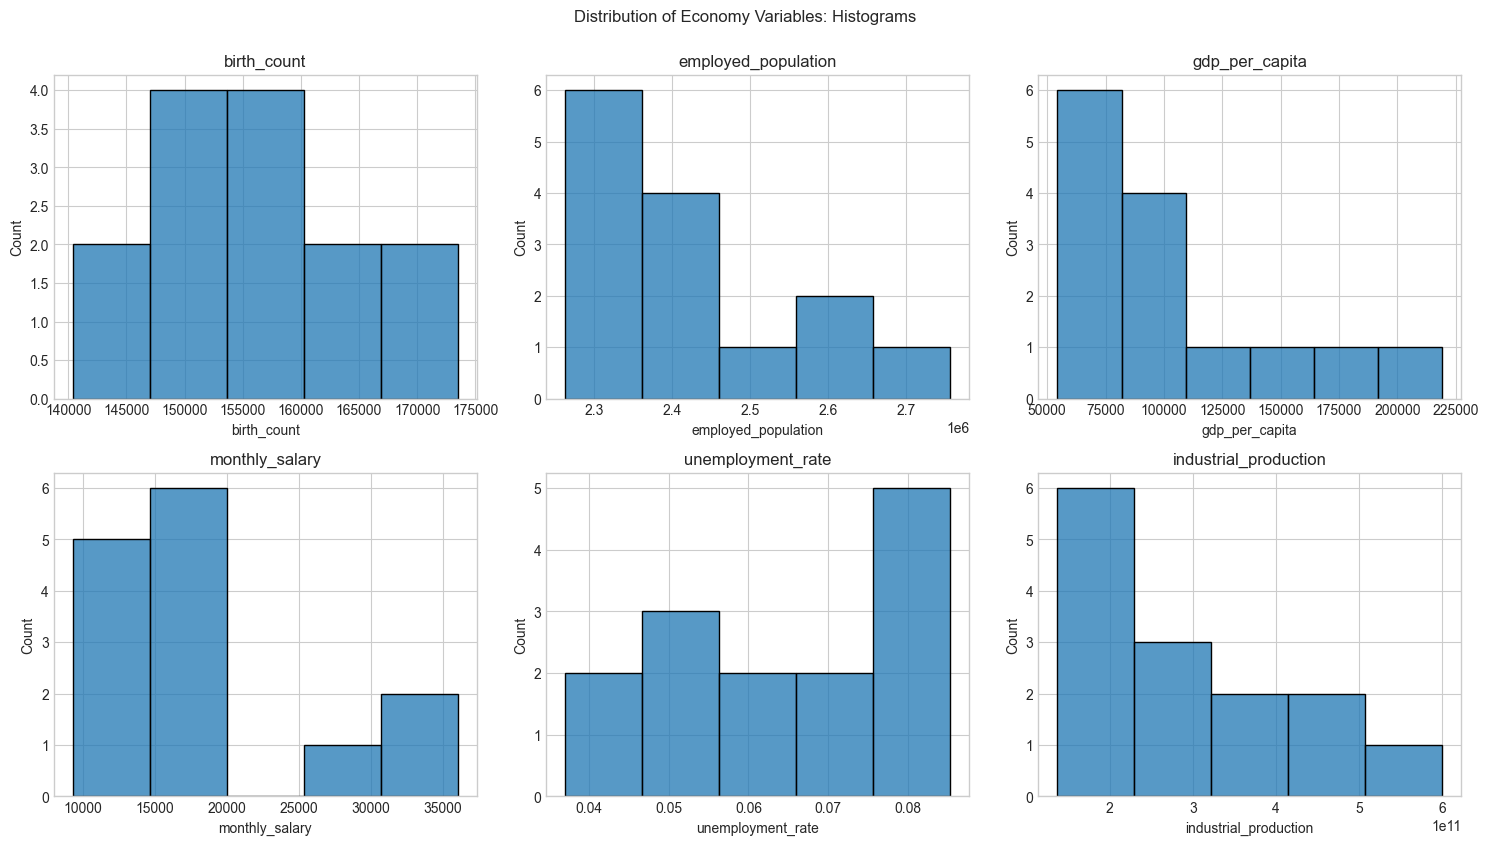

In [357]:
economy_cols = [
    'birth_count', 
    'employed_population', 
    'gdp_per_capita', 
    'monthly_salary', 
    'unemployment_rate', 
    'industrial_production'
]

plt.figure(figsize=(15, 12))
for i, col in enumerate(economy_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(x=df[col])
    plt.title(col)
plt.suptitle('Distribution of Economy Variables: Histograms', y=1)
plt.tight_layout()
plt.show()

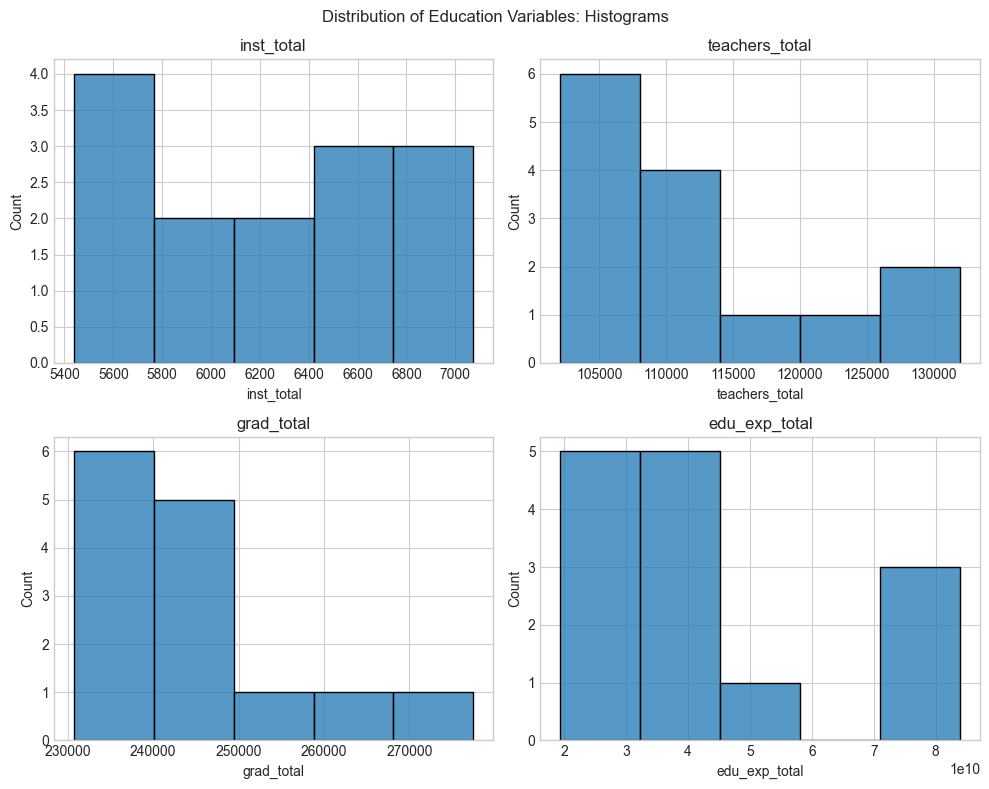

In [358]:
education_cols = [
    'inst_total', 
    'teachers_total', 
    'grad_total',
    'edu_exp_total'
]

plt.figure(figsize=(10, 8))
for i, col in enumerate(education_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(x=df[col])
    plt.title(col)
plt.suptitle('Distribution of Education Variables: Histograms')
plt.tight_layout()
plt.show()

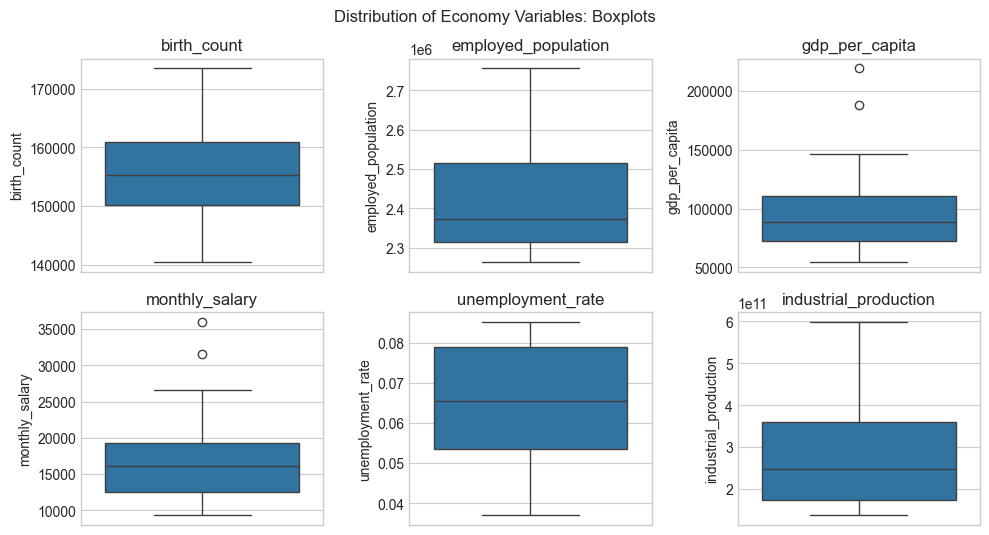

In [359]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(economy_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.suptitle('Distribution of Economy Variables: Boxplots')
plt.tight_layout()
plt.show()

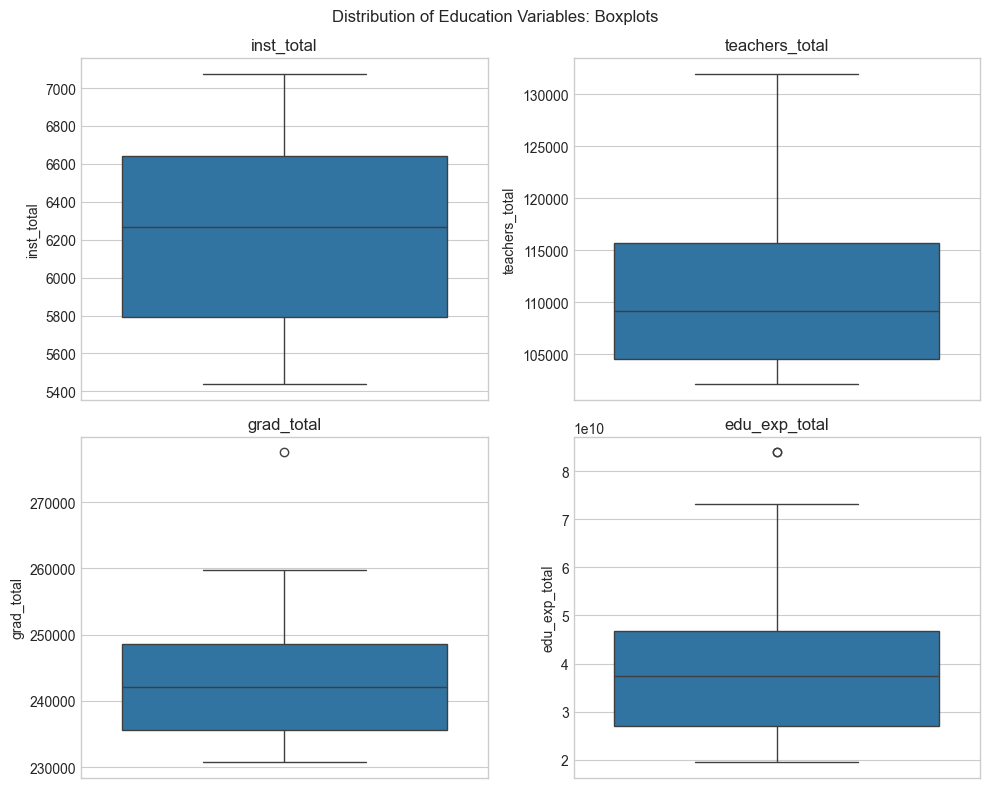

In [360]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(education_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.suptitle('Distribution of Education Variables: Boxplots')
plt.tight_layout()
plt.show()

Most variables are right-skewed, likely because economic values stayed low for a long time. Growth is probably a recent trend.

However, there are three exceptions:
- Birth counts follow a normal distribution because they are shaped by many small, random influences that cancel each other.

- Unemployment rate is the "mirror image" of the others. While, for example, GDP shows growth by climbing from low to high, unemployment shows improvement by dropping from high to low. But the logic is the same.

- Educational facilities show a bimodal pattern because they are driven by government planning rather than random growth. Instead of scaling naturally, they are built in fixed tiers to meet specific population needs in specific regions.

We will investigate the outliers in GDP, salary, education expenditure and graduation totals later; for now, we assume they represent a significant lead in recent times. We will check this, along with the assumption that growth is a recent trend, in the upcoming time series plots.

# Visualizations

## Time Series Plots

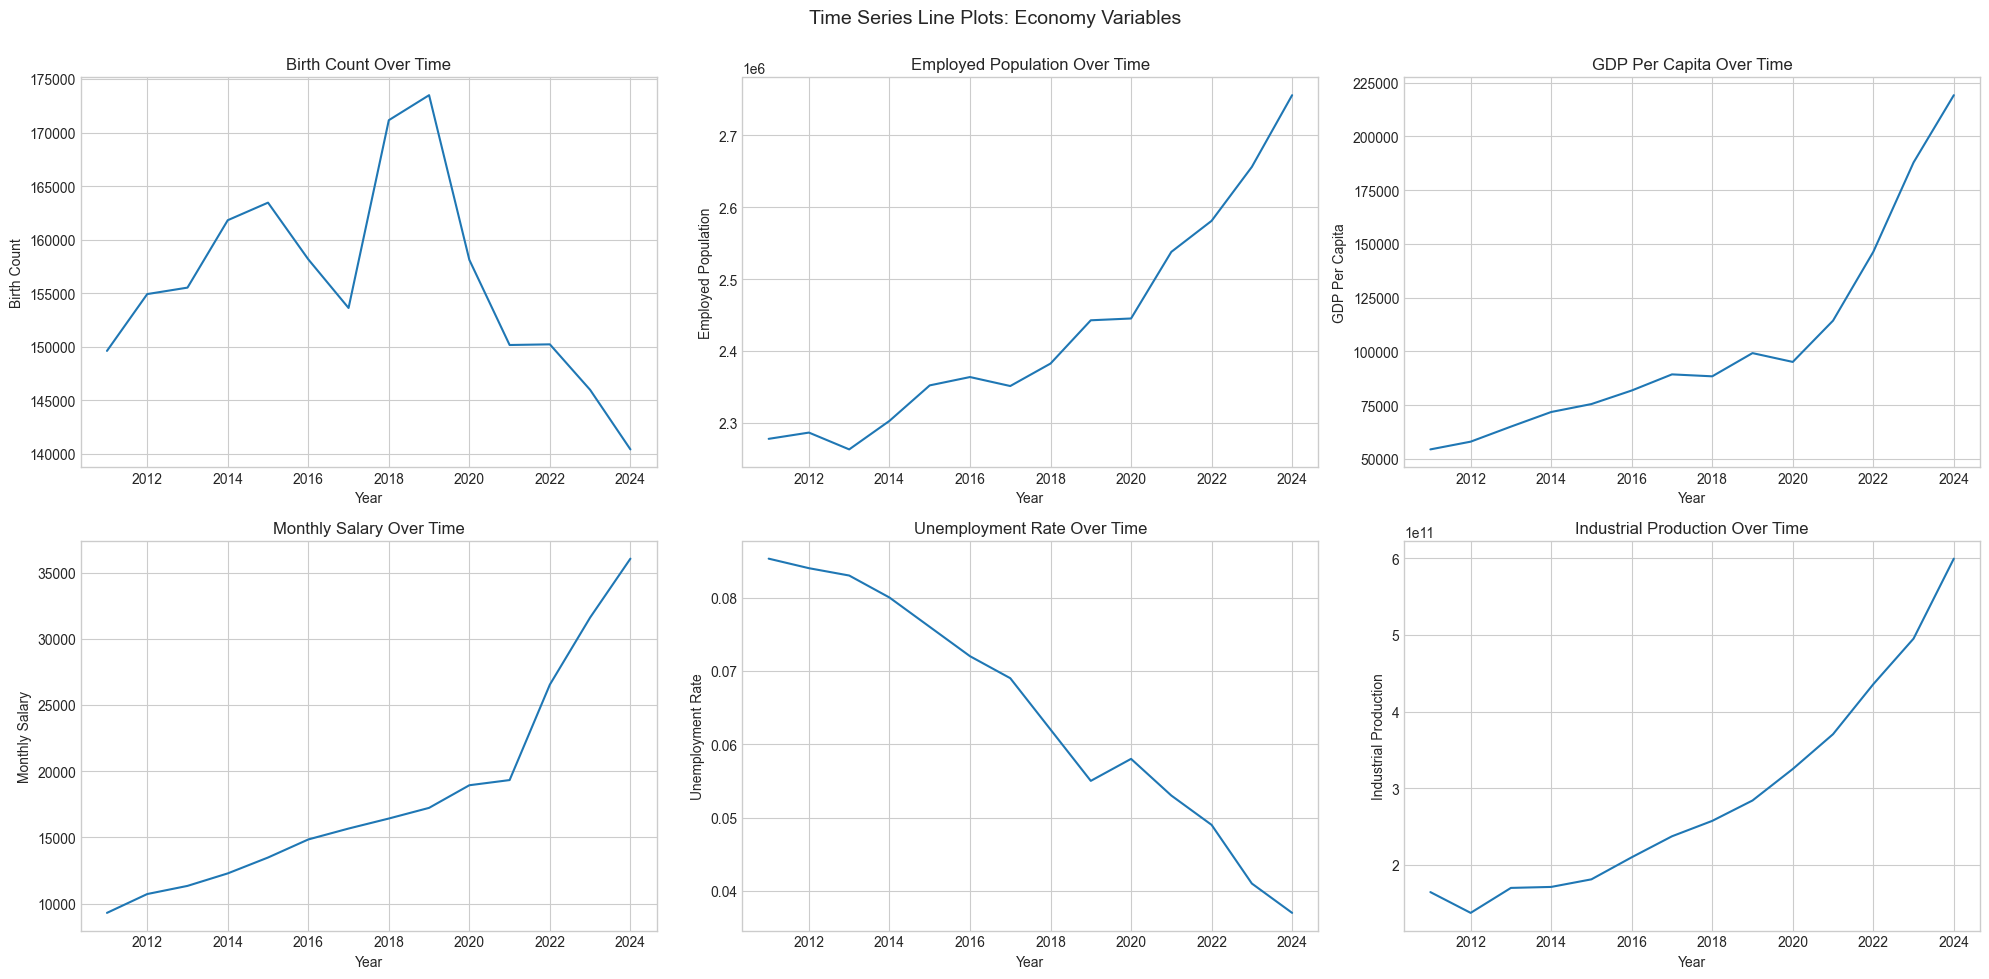

In [361]:
timeseries_eco_plot_configs = {
    'birth_count': {'title': 'Birth Count Over Time', 'ylabel': 'Birth Count'},
    'employed_population': {'title': 'Employed Population Over Time', 'ylabel': 'Employed Population'},
    'gdp_per_capita': {'title': 'GDP Per Capita Over Time', 'ylabel': 'GDP Per Capita'},
    'monthly_salary': {'title': 'Monthly Salary Over Time', 'ylabel': 'Monthly Salary'},
    'unemployment_rate': {'title': 'Unemployment Rate Over Time', 'ylabel': 'Unemployment Rate'},
    'industrial_production': {'title': 'Industrial Production Over Time', 'ylabel': 'Industrial Production'}
}

plt.figure(figsize=(20, 14))
for i, (col, config) in enumerate(timeseries_eco_plot_configs.items(), 1):
    plt.subplot(3, 3, i)
    sns.lineplot(x=df.index, y=df[col])
    plt.title(config['title'])
    plt.xlabel('Year')
    plt.ylabel(config['ylabel'])
plt.suptitle('Time Series Line Plots: Economy Variables', fontsize=14, y=1)
plt.tight_layout()
plt.show()

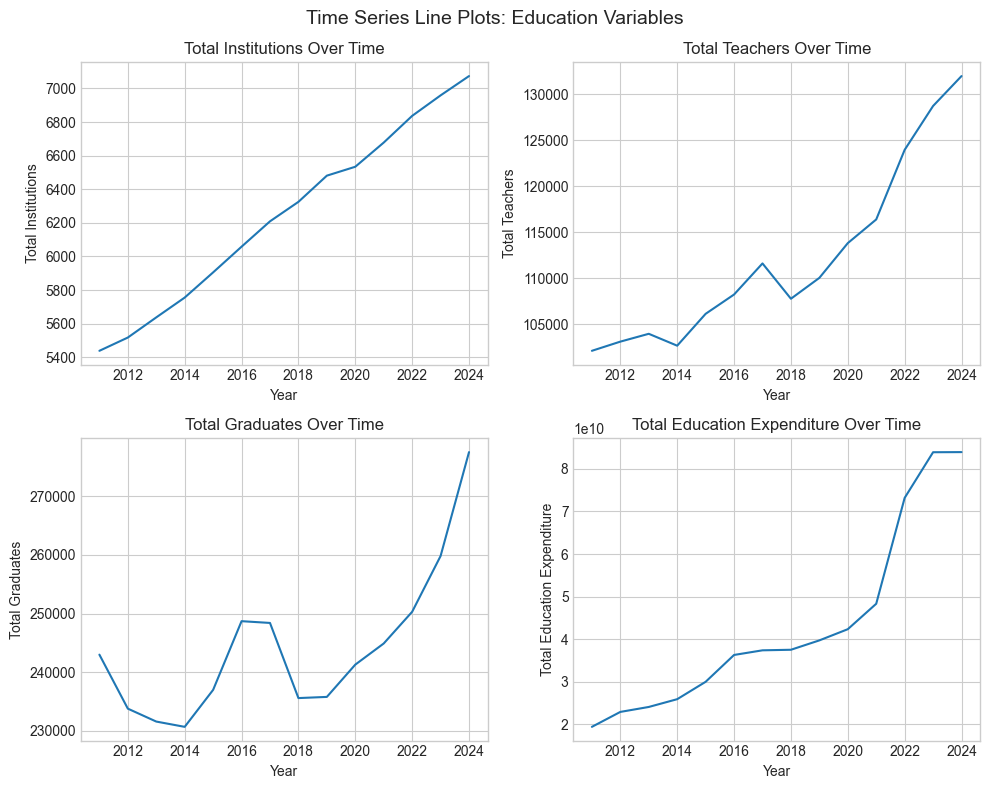

In [362]:
timeseries_edu_plot_configs = {
    'inst_total': {'title': 'Total Institutions Over Time', 'ylabel': 'Total Institutions'},
    'teachers_total': {'title': 'Total Teachers Over Time', 'ylabel': 'Total Teachers'},
    'grad_total': {'title': 'Total Graduates Over Time', 'ylabel': 'Total Graduates'},
    'edu_exp_total': {'title': 'Total Education Expenditure Over Time', 'ylabel': 'Total Education Expenditure'}
}

plt.figure(figsize=(10, 8))
for i, (col, config) in enumerate(timeseries_edu_plot_configs.items(), 1):
    plt.subplot(2, 2, i)
    sns.lineplot(x=df.index, y=df[col])
    plt.title(config['title'])
    plt.xlabel('Year')
    plt.ylabel(config['ylabel'])
plt.suptitle('Time Series Line Plots: Education Variables', fontsize=14)
plt.tight_layout()
plt.show()

The plots revealed that economy and education sectors are undergoing a period of rapid growth. Around 2021, both of them saw a huge, simultaneous jump:

- GDP per Capita, monthly paychecks, and industrial production all started growing extremely fast.

- The government starts spending much more on education, and the number of graduates (as well as teachers) spikes.

- Unemployment rate drops lowest (under 4%), and the number of employed people rapidly increases, reaching nearly 2.8 million.

But, in contrast to these trends, birth counts crash to a 13-year low. Additionally, despite the surge in spending, the construction of education institutions remained steadily positive throughout the entire period, showing no sudden spike.

## Composition of Education Expenditure by Level

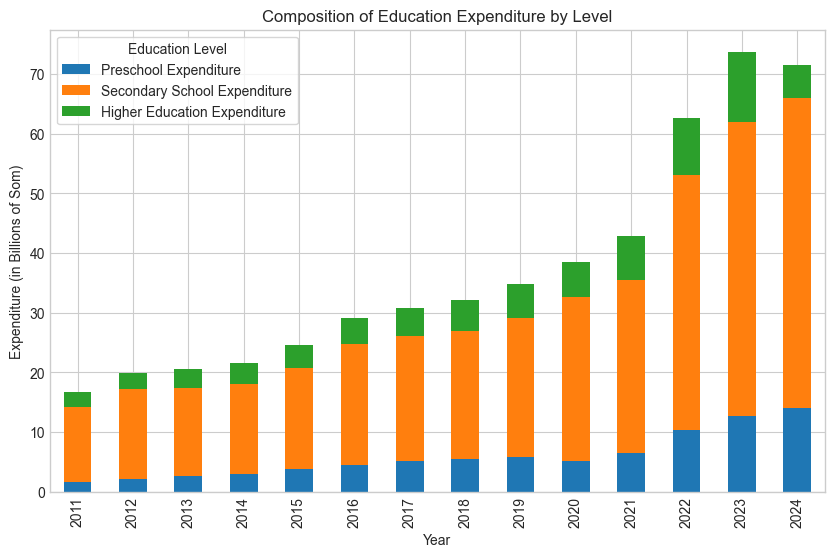

In [363]:
cols = ['edu_exp_preschool', 'edu_exp_secondary', 'edu_exp_higher']

(df[cols] / 1000000000).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Composition of Education Expenditure by Level')
plt.xlabel('Year')
plt.ylabel('Expenditure (in Billions of Som)')
plt.legend(['Preschool Expenditure', 'Secondary School Expenditure', 'Higher Education Expenditure'], 
           title='Education Level', 
           frameon=True)
plt.gca().ticklabel_format(axis='y', style='plain')
plt.show()

Total spending remained flat until 2021, then skyrocketed to over 70 billion som by 2024 — over four times the 2011 level. 

Despite this surge, the composition of spending stayed nearly identical throughout: secondary school consistently absorbed 70–80% of the budget, with preschool and higher education as minor shares. 

This means we are essentially looking at the same funding model scaled up — a useful baseline to keep in mind when interpreting any further trends.

## Education Expenditure vs. Graduates with Cost per Graduate as Bubble Size

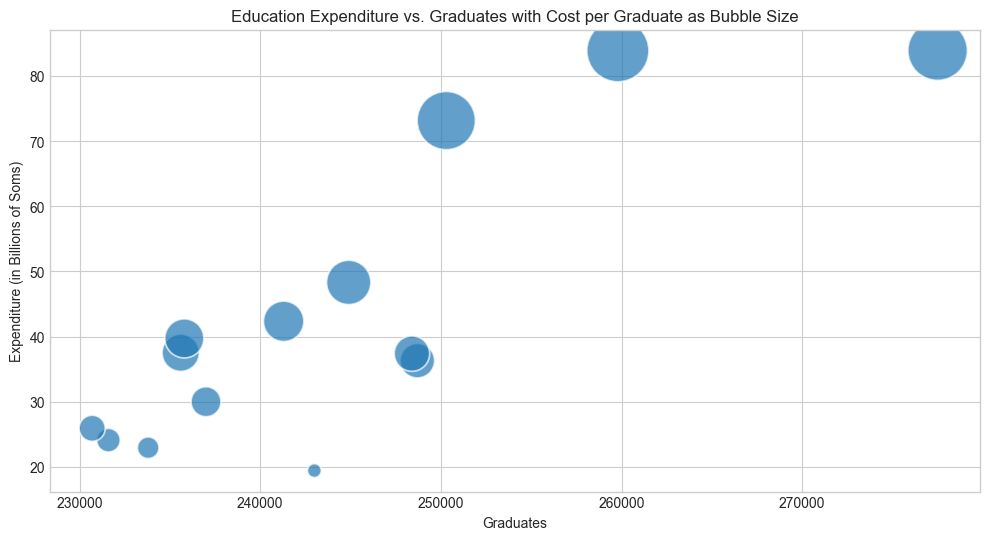

In [364]:
cost_per_grad = df['edu_exp_total'] / df['grad_total']

size_min, size_max = 100, 2000
size_norm = (cost_per_grad - cost_per_grad.min()) / (cost_per_grad.max() - cost_per_grad.min())
bubble_size = size_min + size_norm * (size_max - size_min)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    x=df['grad_total'], 
    y=df['edu_exp_total'] / 1000000000,
    s=bubble_size,
    sizes=(size_min, size_max),
    alpha=0.7
)
plt.gca().ticklabel_format(axis='y', style='plain')
plt.title('Education Expenditure vs. Graduates with Cost per Graduate as Bubble Size')
plt.xlabel('Graduates')
plt.ylabel('Expenditure (in Billions of Soms)')
plt.show()